## Business Intelligence Internship – Data Simulation & Analytics Assignment

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
policy=pd.read_csv("policy_sales_data.csv",parse_dates=["Policy_Purchase_Date","Policy_Start_Date","Policy_End_Date"],dayfirst=True)
claims=pd.read_csv("claims_data.csv",parse_dates=["Claim_Date"],dayfirst=True)

In [3]:
policy.head()

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure
0,C0000001,V0000001,100000,100,2024-01-01,2024-12-31,2025-12-31,1
1,C0000002,V0000002,100000,100,2024-01-01,2024-12-31,2025-12-31,1
2,C0000003,V0000003,100000,100,2024-01-01,2024-12-31,2025-12-31,1
3,C0000004,V0000004,100000,100,2024-01-01,2024-12-31,2025-12-31,1
4,C0000005,V0000005,100000,100,2024-01-01,2024-12-31,2025-12-31,1


In [4]:
claims.head()

,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,CL0000001,C0016401,V0016401,10000,2025-01-06,1
1,CL0000002,C0016402,V0016402,10000,2025-01-06,1
2,CL0000003,C0016403,V0016403,10000,2025-01-06,1
3,CL0000004,C0016404,V0016404,10000,2025-01-06,1
4,CL0000005,C0016405,V0016405,10000,2025-01-06,1


### Part 3: Analytical Queries

#### 1. Total Premium Collected in 2024

In [5]:
total_premium = policy["Premium"].sum()
print(total_premium)

240000000


#### 2. Total Claim Cost Per Year (Monthly Breakdown)

In [6]:
claims["Year"] = claims["Claim_Date"].dt.year
claims["Month"] = claims["Claim_Date"].dt.month

monthly_claims = claims.groupby(["Year","Month"])["Claim_Amount"].sum().reset_index()

print(monthly_claims)

    Year  Month  Claim_Amount
0   2025      1      32790000
1   2025      2      32820000
2   2025      3      32820000
3   2025      4      32790000
4   2025      5      32760000
5   2025      6      32790000
6   2025      7      32790000
7   2025      8      32760000
8   2025      9      32760000
9   2025     10      32790000
10  2025     11      32790000
11  2025     12      32790000
12  2026      1      52550000
13  2026      2      47450000


#### 3. Claim Cost to Premium Ratio by Policy Tenure

In [7]:
merged = claims.merge(policy, on=["Customer_ID","Vehicle_ID"])

ratio_by_tenure = merged.groupby("Policy_Tenure").agg({
    "Claim_Amount":"sum",
    "Premium":"sum"
})

ratio_by_tenure["Claim_to_Premium_Ratio"] = ratio_by_tenure["Claim_Amount"] / ratio_by_tenure["Premium"]

print(ratio_by_tenure)

               Claim_Amount  Premium  Claim_to_Premium_Ratio
Policy_Tenure                                               
1                  78720000   787200              100.000000
2                 118190000  2363800               50.000000
3                 157180000  4715400               33.333333
4                 139360000  5574400               25.000000


#### 4. Claim Cost to Premium Ratio by Policy Sale Month

In [ ]:
policy["Sale_Month"] = policy["Policy_Purchase_Date"].dt.month

merged = claims.merge(policy, on=["Customer_ID","Vehicle_ID"])

ratio_by_month = merged.groupby("Sale_Month").agg({
    "Claim_Amount":"sum",
    "Premium":"sum"
})

ratio_by_month["Claim_to_Premium_Ratio"] = ratio_by_month["Claim_Amount"] / ratio_by_month["Premium"]

print(ratio_by_month)

            Claim_Amount  Premium  Claim_to_Premium_Ratio
Sale_Month                                               
1               96710000  3343600               28.923914
2               36100000   918800               39.290379
3               36100000   918800               39.290379
4               36070000   918000               39.291939
5               36040000   917200               39.293502
6               36070000   918000               39.291939
7               36070000   918000               39.291939
8               36040000   917200               39.293502
9               36040000   917200               39.293502
10              36070000   918000               39.291939
11              36070000   918000               39.291939
12              36070000   918000               39.291939


#### 5. Estimate Total Future Claim Liability

In [9]:
claimed = claims["Vehicle_ID"].unique()

all_vehicles = policy["Vehicle_ID"]

not_claimed = policy[~policy["Vehicle_ID"].isin(claimed)]

future_claim_liability = len(not_claimed) * 10000

print(future_claim_liability)

9545910000


#### 6. Earned Premium Calculation

##### (i) Earned Premium Calculation

In [10]:
policy["Policy_Start_Date"] = pd.to_datetime(policy["Policy_Start_Date"])
policy["Policy_End_Date"] = pd.to_datetime(policy["Policy_End_Date"])

policy["Tenure_Days"] = (policy["Policy_End_Date"] - policy["Policy_Start_Date"]).dt.days

In [11]:
policy["Daily_Premium"] = policy["Premium"] / policy["Tenure_Days"]

In [12]:
cutoff = pd.Timestamp("2026-02-28")

policy["Earned_Days"] = (cutoff - policy["Policy_Start_Date"]).dt.days

policy["Earned_Days"] = policy["Earned_Days"].clip(lower=0)

policy["Earned_Premium"] = policy["Daily_Premium"] * policy["Earned_Days"]

earned_premium = policy["Earned_Premium"].sum()

print(earned_premium)

66142672.48450786


##### (ii) Monthly expected premium (46 months remaining)

In [13]:
remaining_premium = policy["Premium"].sum() - earned_premium

monthly_expected = remaining_premium / 46

print(monthly_expected)

3779507.119902003


### Part 4: Bonus Questions

#### 1. Identify Which Policy Tenure Is Most Profitable

In [16]:
ratio_by_tenure = merged.groupby("Policy_Tenure").agg({
    "Claim_Amount":"sum",
    "Premium":"sum"
})

ratio_by_tenure["Loss_Ratio"] = ratio_by_tenure["Claim_Amount"] / ratio_by_tenure["Premium"]
# The policy tenure with the lowest loss ratio is the most profitable because the company collects more premium relative to claims paid.

In [17]:
ratio_by_tenure

,Claim_Amount,Premium,Loss_Ratio
Policy_Tenure,,,
1,78720000,787200,100.000000
2,118190000,2363800,50.000000
3,157180000,4715400,33.333333
4,139360000,5574400,25.000000


#### 2. Build a Simple Claim Trend Visualization

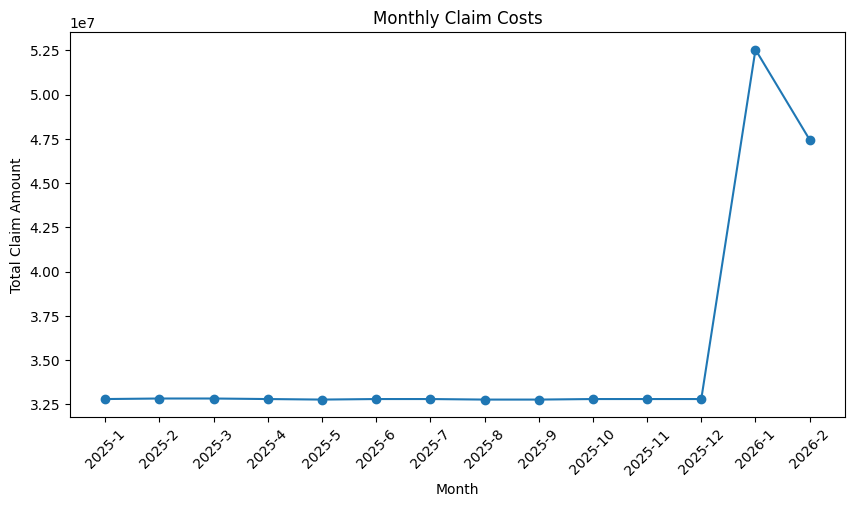

In [ ]:
monthly_claims = claims.groupby(["Year","Month"])["Claim_Amount"].sum().reset_index()

monthly_claims["Date"] = monthly_claims["Year"].astype(str) + "-" + monthly_claims["Month"].astype(str)

plt.figure(figsize=(10,5))
plt.plot(monthly_claims["Date"], monthly_claims["Claim_Amount"], marker="o")

plt.xticks(rotation=45)
plt.title("Monthly Claim Costs")
plt.xlabel("Month")
plt.ylabel("Total Claim Amount")

plt.show()

#### 3. Estimate the Loss Ratio for Entire Portfolio

In [18]:
total_claims = claims["Claim_Amount"].sum()
total_premium = policy["Premium"].sum()

portfolio_loss_ratio = total_claims / total_premium

print(portfolio_loss_ratio)
# A loss ratio below 1 means the company collects more premium than it pays in claims.

2.0560416666666668


#### 4. Estimate Impact of 5% Increase in Claim Frequency

In [ ]:
future_claims = total_claims * 1.05
future_loss_ratio = future_claims / total_premium
future_loss_ratio
# If claim frequency increases by 5%, the loss ratio will increase proportionally, reducing profitability for the insurer.

2.15884375